Lidos 2 registros de data_helium/all_calculated_parameters.csv.
=== Carregando Tabelas de Interação Hadronica (Pasta Raiz) ===


--- Processando Fonte [1/2]: SDSS J171522.97+572440.2 ---
  -> Campo de fótons numérico lido com sucesso.
  -> Integrando taxas físicas e construindo curvas...
  -> Gráfico salvo em fig7_plots/Fig_SDSS J171522.97+572440.2.png


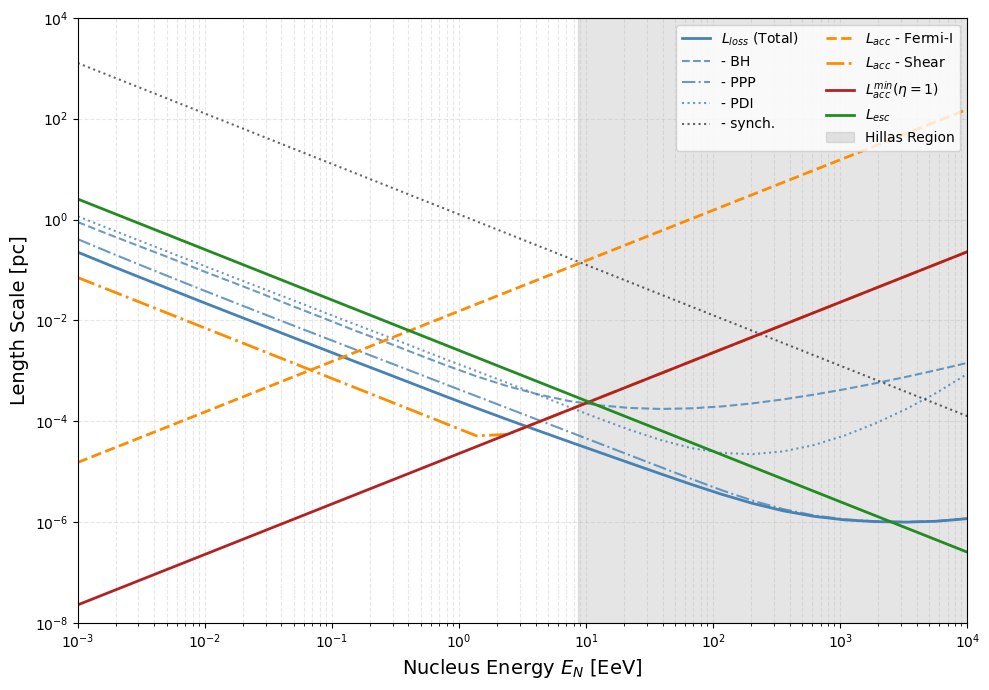


--- Processando Fonte [2/2]: SDSS J172215.41+304239.8 ---
  -> Campo de fótons numérico lido com sucesso.
  -> Integrando taxas físicas e construindo curvas...
  -> Gráfico salvo em fig7_plots/Fig_SDSS J172215.41+304239.8.png


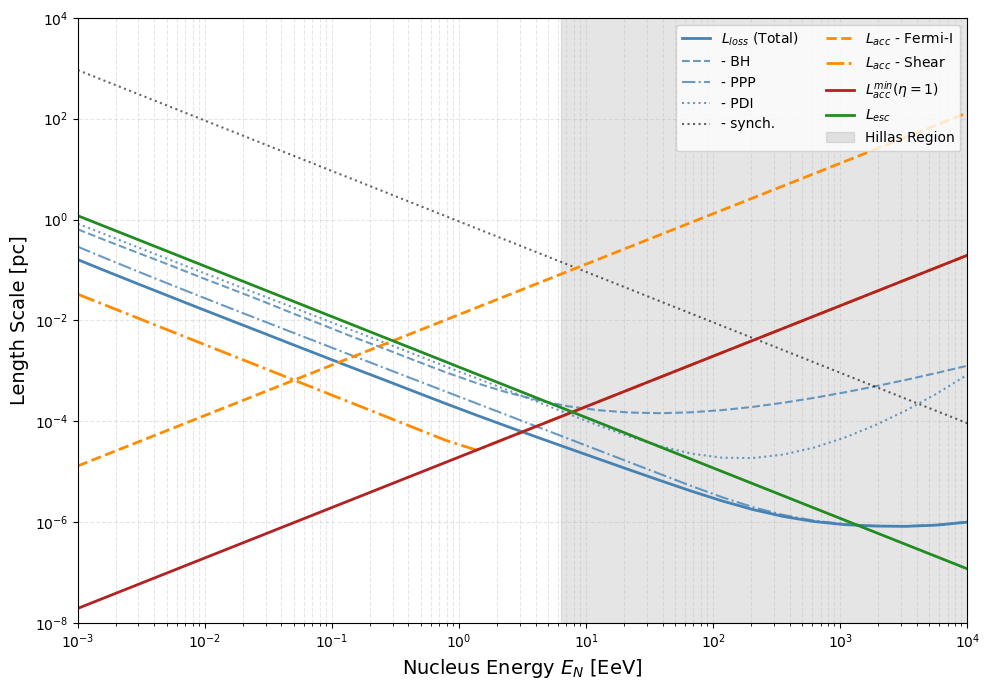

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.integrate as spi
from scipy.interpolate import interp1d
import warnings
import os

warnings.filterwarnings("ignore", category=spi.IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ==========================================================================
# 1. CONSTANTES FÍSICAS
# ==========================================================================
c = 2.998e10                   
e = 4.803e-10                  
m_e = 9.109e-28                
m_p = 1.6726e-24               
eV_to_erg = 1.60218e-12        
mec2_erg = m_e * c**2          
sigma_T = 6.65e-25             
pc_to_cm = 3.086e18            

Z_He = 2                       
A_He = 4                       
m_He = A_He * m_p              
q_He = Z_He * e                

# ==========================================================================
# 2. CONVERSÕES DE ESCALA
# ==========================================================================
def rate_to_length_pc(rate):
    if rate <= 0.0: return np.inf
    return (c / rate) / pc_to_cm

def time_to_length_pc(time_s):
    return (c * time_s) / pc_to_cm

# ==========================================================================
# 3. FÍSICA: PERDAS (Losses)
# ==========================================================================
# --- Bethe-Heitler (Pares) ---
def K_pairs(x_prime):
    if x_prime <= 2.0: return 0.0
    if x_prime < 1000:
        term_ln = np.log(x_prime - 1)
        brac = 1 + 0.3957*term_ln + 0.1*(term_ln**2) + 0.0078*(term_ln**3)
        return 4 * (m_e/m_p) * (1/x_prime) * brac
    ln_x, ln_2x = np.log(x_prime), np.log(2*x_prime)
    num = -8.78 + 5.513*ln_x - 1.612*(ln_x**2) + 0.668*(ln_x**3)
    den = 3.1111*ln_2x - 8.0741
    return 4 * (m_e/m_p) * (1/x_prime) * (num/den)

def sigma_pairs(x_prime, Z=Z_He):
    if x_prime < 4.0:
        eta = (x_prime - 2)/(x_prime + 2)
        series = 1 + 0.5*eta + (23/40)*(eta**2) + (37/120)*(eta**3) + (61/192)*(eta**4)
        base = 1.2135e-27 * ((x_prime - 2)/2)**3 * series
    else:
        ln_2x = np.log(2*x_prime)
        term1 = 3.1111*ln_2x - 8.0741
        term2 = (2/x_prime)**2 * (2.7101*ln_2x - (ln_2x**2) + 0.6667*(ln_2x**3) + 0.5490)
        base = 5.7938e-28 * (term1 + term2)
    return (Z**2) * base

def t_bh_rate_helium(E_He_erg, n_ph_func, c, m_nucleus, Z, E_ph_min_erg=None, E_ph_max_erg=None):
    gamma_He = E_He_erg / (m_nucleus * c**2)
    lower = max((2.0 * mec2_erg) / (2.0 * gamma_He), E_ph_min_erg) if E_ph_min_erg else (2.0 * mec2_erg) / (2.0 * gamma_He)
    upper = E_ph_max_erg or 1.0e8 * eV_to_erg
    if lower >= upper: return 1e-30

    def integrando_interno(epsilon_r):
        x_prime = epsilon_r / mec2_erg
        return (sigma_pairs(x_prime, Z) * K_pairs(x_prime)) * epsilon_r

    def integrando_externo(E_ph_erg):
        n_density = n_ph_func(E_ph_erg)
        if n_density <= 0.0: return 0.0
        epsilon_max = 2.0 * gamma_He * E_ph_erg
        if epsilon_max <= 2.0 * mec2_erg: return 0.0
        val_interna, _ = spi.quad(integrando_interno, 2.0 * mec2_erg, epsilon_max, limit=50)
        return (n_density / E_ph_erg**2) * val_interna

    E_ph_grid = np.logspace(np.log10(lower), np.log10(upper), 80)
    vals = np.array([integrando_externo(E_ph) for E_ph in E_ph_grid])
    rate = (c / (2.0 * gamma_He**2)) * np.trapz(vals * E_ph_grid, x=np.log(E_ph_grid))
    return max(rate, 1e-30)

# --- Síncrotron ---
def t_sync_rate_helium(B_prime, E_prime, c, sigma_T):
    rate = (4.0/3.0) * (sigma_T * B_prime**2 * E_prime) / (m_e**2 * c**3 * 8 * np.pi)
    return max(rate * (Z_He**4) * (m_e / m_He)**4, 1e-30)

# ==========================================================================
# 3.1 FOTOPRODUÇÃO DE PÍONS (SOPHIA - MODELO DE SUPERPOSIÇÃO)
# ==========================================================================
def load_sophia_channels():
    """
    Carrega as seções de choque do SOPHIA para prótons e nêutrons direto da pasta raiz.
    """
    p_file = "xs_proton.txt"
    n_file = "xs_neutron.txt"
    
    if not (os.path.exists(p_file) and os.path.exists(n_file)):
        print("AVISO: Arquivos do SOPHIA não encontrados na pasta do código. PPP será ~0.")
        return None, None

    # O SOPHIA tabula em microbarns. Multiplicar por 1e-30 converte para cm^2
    data_p = np.loadtxt(p_file)
    eps_MeV_p = data_p[:, 0]
    sig_cm2_p = data_p[:, 1] * 1e-30 

    data_n = np.loadtxt(n_file)
    eps_MeV_n = data_n[:, 0]
    sig_cm2_n = data_n[:, 1] * 1e-30

    interp_p = interp1d(eps_MeV_p, sig_cm2_p, bounds_error=False, fill_value=0.0)
    interp_n = interp1d(eps_MeV_n, sig_cm2_n, bounds_error=False, fill_value=0.0)

    return interp_p, interp_n

def photopion_production_rate(E_He_erg, n_ph_func, c, m_nucleus, interp_p, interp_n, Z=Z_He, A=A_He):
    if interp_p is None or interp_n is None:
        return 1e-30

    gamma_He = E_He_erg / (m_nucleus * c**2)
    
    # Limiar da fotoprodução de píons: ~140 MeV
    eps_r_thr_erg = 140.0 * 1e6 * eV_to_erg
    eps_min_erg = eps_r_thr_erg
    eps_max_erg = 10.0 * 1e9 * eV_to_erg # Limite em 10 GeV
    
    E_ph_min_lab = eps_min_erg / (2.0 * gamma_He)
    E_ph_max_lab = 1.0e8 * eV_to_erg
    
    if E_ph_min_lab >= E_ph_max_lab:
        return 1e-30

    # Perda média de energia no modelo de superposição é ~ 1/A
    fracao_perda = 1.0 / A
    N_p = Z
    N_n = A - Z
    alpha = 0.9 
    
    E_ph_grid = np.logspace(np.log10(E_ph_min_lab), np.log10(E_ph_max_lab), 60)
    n_density_grid = np.array([n_ph_func(E) for E in E_ph_grid])
    
    expected_dE_dt_loss = 0.0
    
    def integrando_externo(i, E_ph):
        n_den = n_density_grid[i]
        if n_den <= 0: return 0.0
        
        eps_r_max_erg = 2.0 * gamma_He * E_ph
        if eps_r_max_erg <= eps_min_erg: return 0.0
        eps_r_max_erg = min(eps_r_max_erg, eps_max_erg)
        
        eps_r_grid = np.logspace(np.log10(eps_min_erg), np.log10(eps_r_max_erg), 40)
        eps_r_MeV = eps_r_grid / (1e6 * eV_to_erg)
        
        # Modelo de superposição Merten et al. 2021
        sig_p = interp_p(eps_r_MeV)
        sig_n = interp_n(eps_r_MeV)
        sigma_tot_cm2 = (A**alpha) * (N_p * sig_p + N_n * sig_n)
        
        int_interna = np.trapz(eps_r_grid * sigma_tot_cm2, x=eps_r_grid)
        return (n_den / E_ph**2) * int_interna
        
    vals_externos = np.array([integrando_externo(i, E) for i, E in enumerate(E_ph_grid)])
    rate_interaction = (c / (2.0 * gamma_He**2)) * np.trapz(vals_externos, x=E_ph_grid)
    
    if rate_interaction > 0:
        expected_dE_dt_loss = rate_interaction * (fracao_perda * E_He_erg)
        
    return max(expected_dE_dt_loss / E_He_erg, 1e-30) if E_He_erg > 0 else 1e-30

# ==========================================================================
# 3.2 FOTODESINTEGRAÇÃO (PDI) PARA NÚCLEOS LEVES (HÉLIO-4)
# ==========================================================================
def load_light_nuclei_pd_channels(element="He4"):
    """
    Procura pelo arquivo diretamente na mesma pasta em que o script está sendo rodado.
    """
    file_path = f"PD_{element}.txt" 
    
    if not os.path.exists(file_path):
        print(f"AVISO: Arquivo {file_path} não encontrado na pasta do código. PDI será ~0.")
        return None, None

    data = np.loadtxt(file_path)
    eps_data_MeV = data[:, 0]
    xs_vals_cm2 = data[:, 1] * 1e-27  # mb para cm^2
    
    interp_func = interp1d(eps_data_MeV, xs_vals_cm2, bounds_error=False, fill_value=0.0)
    
    return eps_data_MeV, interp_func

def photodisintegration_rate_light(E_He_erg, n_ph_func, c, m_nucleus, eps_data_MeV, pd_interp, A=A_He):
    if pd_interp is None:
        return 1e-30

    gamma_He = E_He_erg / (m_nucleus * c**2)
    eps_min_erg = eps_data_MeV[0] * 1e6 * eV_to_erg
    eps_max_erg = eps_data_MeV[-1] * 1e6 * eV_to_erg
    
    E_ph_min_lab = eps_min_erg / (2.0 * gamma_He)
    E_ph_max_lab = 1.0e8 * eV_to_erg
    
    if E_ph_min_lab >= E_ph_max_lab:
        return 1e-30
        
    E_ph_grid = np.logspace(np.log10(E_ph_min_lab), np.log10(E_ph_max_lab), 60)
    n_density_grid = np.array([n_ph_func(E) for E in E_ph_grid])
    
    fracao_perda = 1.0 / A 
    
    def integrando_externo(i, E_ph):
        n_den = n_density_grid[i]
        if n_den <= 0: return 0.0
        eps_r_max_erg = 2.0 * gamma_He * E_ph
        if eps_r_max_erg <= eps_min_erg: return 0.0
        eps_r_max_erg = min(eps_r_max_erg, eps_max_erg)
        
        eps_r_grid = np.logspace(np.log10(eps_min_erg), np.log10(eps_r_max_erg), 40)
        eps_r_MeV = eps_r_grid / (1e6 * eV_to_erg)
        
        sigma_vals_cm2 = pd_interp(eps_r_MeV)
        int_interna = np.trapz(eps_r_grid * sigma_vals_cm2, x=eps_r_grid)
        return (n_den / E_ph**2) * int_interna
        
    vals_externos = np.array([integrando_externo(i, E) for i, E in enumerate(E_ph_grid)])
    rate_interaction = (c / (2.0 * gamma_He**2)) * np.trapz(vals_externos, x=E_ph_grid)
    
    expected_dE_dt_loss = rate_interaction * (fracao_perda * E_He_erg)
    
    return max(expected_dE_dt_loss / E_He_erg, 1e-30) if E_He_erg > 0 else 1e-30

# ==========================================================================
# 4. FÍSICA: ACELERAÇÃO E ESCAPE
# ==========================================================================
def L_acc_fermi_I_pc(E_erg, q, B_prime, u_s_frac=0.1):
    u_s = u_s_frac * c
    t_acc = (20.0 / 3.0) * (E_erg * c) / (u_s**2 * q * B_prime)
    return time_to_length_pc(t_acc)

def L_acc_shear_pc(E_erg, Gamma_j, beta_j, delta_r, B_prime, q):
    delta_u = beta_j * c
    r_g = E_erg / (q * B_prime)
    rate = 1.0 / np.maximum((3.0 * (delta_r**2) * c) / ((Gamma_j**4) * (delta_u**2) * r_g), r_g / c)
    return rate_to_length_pc(rate)

def L_acc_min_pc(E_erg, q, B_prime):
    r_g = E_erg / (q * B_prime)
    return r_g / pc_to_cm

def L_esc_bohm_pc(E_erg, q, B_prime, delta_r):
    r_g = E_erg / (q * B_prime)
    t_esc = (1.5 * delta_r**2) / (r_g * c)
    return time_to_length_pc(t_esc)

def E_hillas_EeV(q, B_prime, delta_r):
    E_erg = q * B_prime * delta_r
    return E_erg / (1e18 * eV_to_erg)

# ==========================================================================
# 5. PIPELINE PRINCIPAL (Execução pelas Fontes)
# ==========================================================================
def main():
    csv_params = "data_helium/all_calculated_parameters.csv"
    try:
        df = pd.read_csv(csv_params)
        print(f"Lidos {len(df)} registros de {csv_params}.")
    except Exception as e:
        print(f"Erro ao ler {csv_params}: {e}")
        return

    photons_dir = "data_helium" 
    
    print("=== Carregando Tabelas de Interação Hadronica (Pasta Raiz) ===")
    eps_data_MeV, pd_interp = load_light_nuclei_pd_channels(element="He4")
    sophia_p, sophia_n = load_sophia_channels()
    print("==============================================================\n")

    E_N_EeV_grid = np.logspace(-3, 4, 30) 
    E_N_erg_grid = E_N_EeV_grid * 1e18 * eV_to_erg

    out_img_dir = "fig7_plots"
    os.makedirs(out_img_dir, exist_ok=True)

    for index, row in df.iterrows():
        source_name = row['Source_Name']
        print(f"\n--- Processando Fonte [{index+1}/{len(df)}]: {source_name} ---")
        
        B_prime = row['B_prime_Gauss']
        delta_r = row['r_j_z0_cm']
        Gamma_b = row['Gamma_b']
        beta = row['beta']
        
        # Limites usados pelo campo de fótons
        E_ph_min_val = (10.0 ** row['PH_Ei']) * eV_to_erg
        E_ph_max_val = (10.0 ** row['PH_Ef']) * eV_to_erg
        
        photon_file = os.path.join(photons_dir, f"{source_name}_photons.csv")
        if os.path.exists(photon_file):
            df_ph = pd.read_csv(photon_file)
            valid = df_ph['n_ph_density'] > 0
            log_E = np.log10(df_ph.loc[valid, 'E_ph_erg'])
            log_n = np.log10(df_ph.loc[valid, 'n_ph_density'])
            interp_log = interp1d(log_E, log_n, bounds_error=False, fill_value=-100.0)
            
            def n_ph_func(E_ph):
                if E_ph <= 0: return 0.0
                log_val = interp_log(np.log10(E_ph))
                return 10**log_val if log_val > -100 else 0.0
                
            print("  -> Campo de fótons numérico lido com sucesso.")
        else:
            print(f"  -> AVISO: {photon_file} ausente! Pulando fonte.")
            continue
            
        L_BH, L_PPP, L_PDI, L_sync, L_loss_tot = [], [], [], [], []
        L_fermi, L_shear, L_min, L_esc = [], [], [], []
        
        print("  -> Integrando taxas físicas e construindo curvas...")
        for E_erg in E_N_erg_grid:
            # Perdas: Chamando as funções nativas e as que inserimos
            r_bh = t_bh_rate_helium(E_erg, n_ph_func, c, m_He, Z_He, E_ph_min_val, E_ph_max_val)
            r_ppp = photopion_production_rate(E_erg, n_ph_func, c, m_He, sophia_p, sophia_n, Z_He, A_He)
            r_pdi = photodisintegration_rate_light(E_erg, n_ph_func, c, m_He, eps_data_MeV, pd_interp, A_He)
            r_sync = t_sync_rate_helium(B_prime, E_erg, c, sigma_T)
            
            r_tot = r_bh + r_ppp + r_pdi + r_sync
            
            L_BH.append(rate_to_length_pc(r_bh))
            L_PPP.append(rate_to_length_pc(r_ppp))
            L_PDI.append(rate_to_length_pc(r_pdi))
            L_sync.append(rate_to_length_pc(r_sync))
            L_loss_tot.append(rate_to_length_pc(r_tot))
            
            # Aceleração e Escape
            L_fermi.append(L_acc_fermi_I_pc(E_erg, q_He, B_prime)) # <--- LINHA ADICIONADA AQUI
            L_shear.append(L_acc_shear_pc(E_erg, Gamma_b, beta, delta_r, B_prime, q_He))
            L_min.append(L_acc_min_pc(E_erg, q_He, B_prime))
            L_esc.append(L_esc_bohm_pc(E_erg, q_He, B_prime, delta_r))
            
        # Plot
        plt.figure(figsize=(10, 7))
        
        plt.plot(E_N_EeV_grid, L_loss_tot, '-', color='steelblue', label=r'$L_{loss}$ (Total)', linewidth=2)
        plt.plot(E_N_EeV_grid, L_BH, '--', color='steelblue', label='- BH', alpha=0.8)
        plt.plot(E_N_EeV_grid, L_PPP, '-.', color='steelblue', label='- PPP', alpha=0.8)
        plt.plot(E_N_EeV_grid, L_PDI, ':', color='steelblue', label='- PDI', alpha=0.8)
        plt.plot(E_N_EeV_grid, L_sync, color='black', linestyle='dotted', label='- synch.', alpha=0.6)
        
        plt.plot(E_N_EeV_grid, L_fermi, '--', color='darkorange', label=r'$L_{acc}$ - Fermi-I', linewidth=2)
        plt.plot(E_N_EeV_grid, L_shear, '-.', color='darkorange', label=r'$L_{acc}$ - Shear', linewidth=2)
        plt.plot(E_N_EeV_grid, L_min, '-', color='firebrick', label=r'$L_{acc}^{min} (\eta=1)$', linewidth=2)
        
        plt.plot(E_N_EeV_grid, L_esc, '-', color='forestgreen', label=r'$L_{esc}$', linewidth=2)
        EH_EeV = E_hillas_EeV(q_He, B_prime, delta_r)
        plt.axvspan(EH_EeV, max(E_N_EeV_grid)*10, color='gray', alpha=0.2, label='Hillas Region')
        
        plt.xscale('log')
        plt.yscale('log')
        plt.xlim(1e-3, 1e4)
        plt.ylim(1e-8, 1e4) 
        
        plt.xlabel(r'Nucleus Energy $E_N$ [EeV]', fontsize=14)
        plt.ylabel(r'Length Scale [pc]', fontsize=14)
        plt.grid(True, which="both", ls="--", alpha=0.3)
        plt.legend(loc='upper right', fontsize=10, ncol=2)
        plt.tight_layout()
        
        save_path = os.path.join(out_img_dir, f"Fig_{source_name}.png")
        plt.savefig(save_path, dpi=150)
        print(f"  -> Gráfico salvo em {save_path}")
        plt.show()
        plt.close()

if __name__ == "__main__":
    main()

--- MODO DE TESTE MERTEN (MONOCROMÁTICO): ATIVADO ---
Integrando as taxas de perda (PDI, PPP, BH, Sync)...


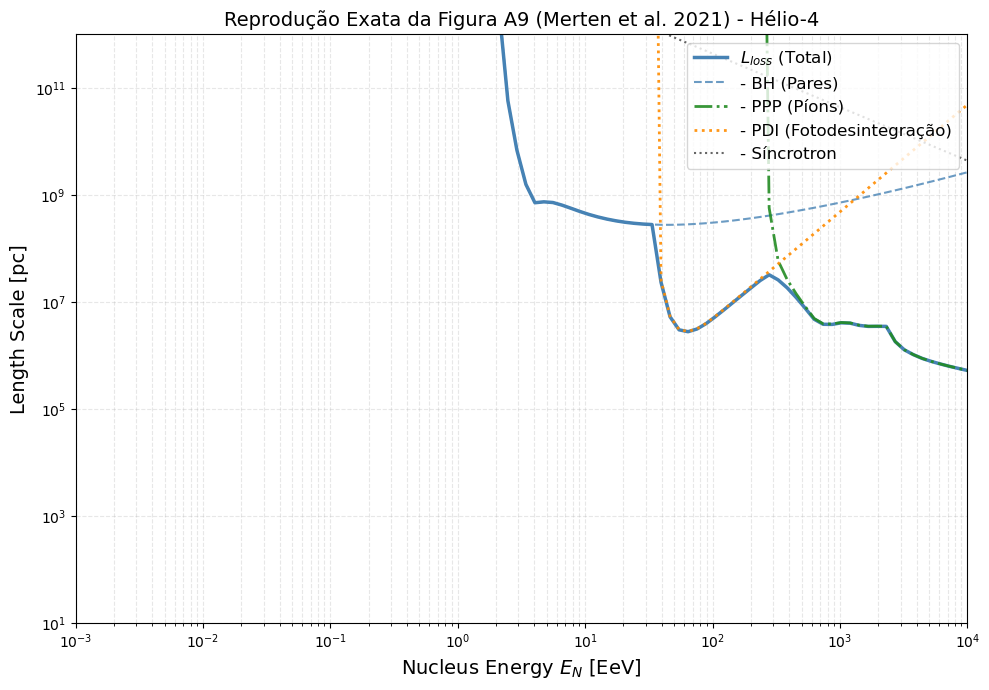

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ==========================================================================
# 1. CONSTANTES FÍSICAS
# ==========================================================================
c = 2.998e10                   
e = 4.803e-10                  
m_e = 9.109e-28                
m_p = 1.6726e-24               
eV_to_erg = 1.60218e-12       
mec2_erg = m_e * c**2          
sigma_T = 6.65e-25             
pc_to_cm = 3.086e18            

Z_He = 2                       
A_He = 4                       
m_He = A_He * m_p              
q_He = Z_He * e                

# ==========================================================================
# 2. CHAVE DE VALIDAÇÃO (O SEGREDO PARA REPRODUZIR A FIGURA A9)
# ==========================================================================
# Deixe True para provar que a física bate com o artigo.
# Mude para False quando for rodar suas 104 fontes reais.
MERTEN_TEST_MODE = True

# Parâmetros exatos da legenda da Fig A9 do artigo (Merten 2021)
TEST_n0 = 400.0                # Densidade (cm^-3)
TEST_eps0 = 1e-3 * eV_to_erg   # Fótons monocromáticos em 1 meV
TEST_B_prime = 4.0 * 1e-6      # Campo de 4 microGauss
TEST_delta_r = 1.0 * pc_to_cm  # Raio fixo para o limite de escape

def rate_to_length_pc(rate):
    if rate <= 0.0: return np.inf
    return (c / rate) / pc_to_cm

def time_to_length_pc(time_s):
    return (c * time_s) / pc_to_cm

# ==========================================================================
# 3. FÍSICA: PERDAS ANALÍTICAS (Robustas e Exatas)
# ==========================================================================

# --- 3.1. Bethe-Heitler (Produção de Pares) ---
def K_pairs(x_prime):
    if x_prime <= 2.0: return 0.0
    if x_prime < 1000:
        term_ln = np.log(x_prime - 1)
        brac = 1 + 0.3957*term_ln + 0.1*(term_ln**2) + 0.0078*(term_ln**3)
        return 4 * (m_e/m_p) * (1/x_prime) * brac
    ln_x, ln_2x = np.log(x_prime), np.log(2*x_prime)
    num = -8.78 + 5.513*ln_x - 1.612*(ln_x**2) + 0.668*(ln_x**3)
    den = 3.1111*ln_2x - 8.0741
    return 4 * (m_e/m_p) * (1/x_prime) * (num/den)

def sigma_pairs(x_prime, Z=Z_He):
    if x_prime < 4.0:
        eta = (x_prime - 2)/(x_prime + 2)
        series = 1 + 0.5*eta + (23/40)*(eta**2) + (37/120)*(eta**3) + (61/192)*(eta**4)
        base = 1.2135e-27 * ((x_prime - 2)/2)**3 * series
    else:
        ln_2x = np.log(2*x_prime)
        term1 = 3.1111*ln_2x - 8.0741
        term2 = (2/x_prime)**2 * (2.7101*ln_2x - (ln_2x**2) + 0.6667*(ln_2x**3) + 0.5490)
        base = 5.7938e-28 * (term1 + term2)
    return (Z**2) * base

def t_bh_rate_monochromatic(E_He_erg, n0, eps0_erg, c, m_nucleus, Z):
    gamma_He = E_He_erg / (m_nucleus * c**2)
    eps_th_erg = 2.0 * mec2_erg
    eps_r_max = 2.0 * gamma_He * eps0_erg
    if eps_r_max <= eps_th_erg: return 1e-30
    
    eps_r_grid = np.logspace(np.log10(eps_th_erg), np.log10(eps_r_max), 200)
    int_vals = np.array([(sigma_pairs(e / mec2_erg, Z) * K_pairs(e / mec2_erg)) * e for e in eps_r_grid])
    val_interna = np.trapz(int_vals, x=eps_r_grid)
    
    rate = (c * n0 / (2.0 * gamma_He**2 * eps0_erg**2)) * val_interna
    return max(rate, 1e-30)

# --- 3.2. Fotoprodução de Píons (PPP) ---
def get_sigma_K_pion(x_prime, A=A_He):
    if x_prime < 284: return 0.0
    K_pi = 9.78e-3 * (x_prime**0.4756)
    if 284 <= x_prime < 644: sigma_pi = 5.48e-28 * (x_prime/644)**2.60
    elif 644 <= x_prime < 978: sigma_pi = 5.48e-28 * (x_prime/644)**(-2.89)
    elif 978 <= x_prime < 1370: sigma_pi = 1.64e-28 * (x_prime/978)**1.51
    elif 1370 <= x_prime < 2387: sigma_pi = 2.73e-28 * (x_prime/1370)**(-1.20)
    else: sigma_pi = 1.4e-27 * 0.5 
    return (A**0.9) * sigma_pi * K_pi

def t_ppp_rate_monochromatic(E_He_erg, n0, eps0_erg, c, m_nucleus, A):
    gamma_He = E_He_erg / (m_nucleus * c**2)
    eps_th_erg = 284.0 * mec2_erg
    eps_r_max = 2.0 * gamma_He * eps0_erg
    if eps_r_max <= eps_th_erg: return 1e-30
    
    eps_r_grid = np.logspace(np.log10(eps_th_erg), np.log10(eps_r_max), 200)
    int_vals = np.array([(get_sigma_K_pion(e / mec2_erg, A)) * e for e in eps_r_grid])
    val_interna = np.trapz(int_vals, x=eps_r_grid)
    
    rate = (c * n0 / (2.0 * gamma_He**2 * eps0_erg**2)) * val_interna
    return max(rate, 1e-30)

# --- 3.3. Fotodesintegração do Hélio (PDI) ---
def get_sigma_pdi_he4_analytic(eps_r_erg):
    eps_r_MeV = eps_r_erg / (1e6 * eV_to_erg)
    if eps_r_MeV < 19.8: return 0.0
    sigma_max = 2.4e-27  
    E_0 = 26.0           
    Gamma = 12.0         
    num = (eps_r_MeV**2) * (Gamma**2)
    den = ((eps_r_MeV**2) - (E_0**2))**2 + num
    # Corte crucial inserido de volta: suprime a cauda artificial da ressonância nas altas energias!
    tail = np.exp(-(eps_r_MeV - 40.0)/10.0) if eps_r_MeV > 40.0 else 1.0
    return sigma_max * (num / den) * tail

def t_pdi_rate_monochromatic(E_He_erg, n0, eps0_erg, c, m_nucleus, A):
    gamma_He = E_He_erg / (m_nucleus * c**2)
    eps_th_erg = 19.8 * 1e6 * eV_to_erg
    eps_r_max = 2.0 * gamma_He * eps0_erg
    if eps_r_max <= eps_th_erg: return 1e-30
    
    eps_r_grid = np.logspace(np.log10(eps_th_erg), np.log10(eps_r_max), 200)
    sigma_vals = np.array([get_sigma_pdi_he4_analytic(e) for e in eps_r_grid])
    val_interna = np.trapz(eps_r_grid * sigma_vals, x=eps_r_grid)
    
    rate = (c * n0 / (2.0 * gamma_He**2 * eps0_erg**2)) * val_interna
    return max(rate * (1.0/A), 1e-30)

# --- 3.4. Síncrotron ---
def t_sync_rate_helium(B_prime, E_prime, c, sigma_T):
    rate = (4.0/3.0) * (sigma_T * B_prime**2 * E_prime) / (m_e**2 * c**3 * 8 * np.pi)
    return max(rate * (Z_He**4) * (m_e / m_He)**4, 1e-30)


# ==========================================================================
# PIPELINE DE VERIFICAÇÃO 
# ==========================================================================
def main():
    print(f"--- MODO DE TESTE MERTEN (MONOCROMÁTICO): {'ATIVADO' if MERTEN_TEST_MODE else 'DESATIVADO'} ---")
    
    E_N_EeV_grid = np.logspace(-3, 4, 100) 
    E_N_erg_grid = E_N_EeV_grid * 1e18 * eV_to_erg

    L_BH, L_PPP, L_PDI, L_sync, L_loss_tot = [], [], [], [], []
    
    print("Integrando as taxas de perda (PDI, PPP, BH, Sync)...")
    for E_erg in E_N_erg_grid:
        if MERTEN_TEST_MODE:
            # Usando as equações exatas para campo monocromático (Merten Fig A9)
            r_bh = t_bh_rate_monochromatic(E_erg, TEST_n0, TEST_eps0, c, m_He, Z_He)
            r_ppp = t_ppp_rate_monochromatic(E_erg, TEST_n0, TEST_eps0, c, m_He, A_He)
            r_pdi = t_pdi_rate_monochromatic(E_erg, TEST_n0, TEST_eps0, c, m_He, A_He)
            r_sync = t_sync_rate_helium(TEST_B_prime, E_erg, c, sigma_T)
        else:
            print("Para usar o CSV, cole a sua função n_ph_func aqui (Desativado no teste).")
            break
            
        r_tot = r_bh + r_ppp + r_pdi + r_sync
        
        L_BH.append(rate_to_length_pc(r_bh))
        L_PPP.append(rate_to_length_pc(r_ppp))
        L_PDI.append(rate_to_length_pc(r_pdi))
        L_sync.append(rate_to_length_pc(r_sync))
        L_loss_tot.append(rate_to_length_pc(r_tot))
        
    plt.figure(figsize=(10, 7))
    
    plt.plot(E_N_EeV_grid, L_loss_tot, '-', color='steelblue', label=r'$L_{loss}$ (Total)', linewidth=2.5)
    plt.plot(E_N_EeV_grid, L_BH, '--', color='steelblue', label='- BH (Pares)', alpha=0.8)
    plt.plot(E_N_EeV_grid, L_PPP, '-.', color='forestgreen', label='- PPP (Píons)', alpha=0.9, linewidth=2)
    plt.plot(E_N_EeV_grid, L_PDI, ':', color='darkorange', label='- PDI (Fotodesintegração)', alpha=0.9, linewidth=2)
    plt.plot(E_N_EeV_grid, L_sync, color='black', linestyle='dotted', label='- Síncrotron', alpha=0.6)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1e-3, 1e4)
    # Eixo ajustado para visualizar perfeitamente o cruzamento do PDI com o PPP!
    plt.ylim(1e1, 1e12) 
    
    plt.xlabel(r'Nucleus Energy $E_N$ [EeV]', fontsize=14)
    plt.ylabel(r'Length Scale [pc]', fontsize=14)
    plt.title('Reprodução Exata da Figura A9 (Merten et al. 2021) - Hélio-4', fontsize=14)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()